# FORC Processing

This notebook takes a first-order reversal curve measurement from the raw instrument file to a FORC distribution, plots profiles through it, and generates a MagIC measurements table. It starts with the workflow and then goes into more detail. 

For what a FORC diagram represents and the field conventions used throughout, see [the FORC introduction](./FORC_intro.md).

`pmagpy.forc` takes FORC data from a raw Lake Shore (Princeton MicroMag) VSM file, or from a MagIC measurements table, through to diagrams and quantitative profiles.

This notebook goes in this order:

1. **The workflow**: a FORC diagram, profiles, and a ridge-following profile.
2. **The measurement and the distribution**: what a FORC is and how ρ is estimated.
3. **Reading raw instrument files**: units, header tags, and segmentation.
4. **Drift correction**.
5. **Archiving to MagIC**, and reprocessing from a MagIC measurements table.
6. **Choosing the smoothing level**.
7. **Relationship to FORCinel and VARIFORC**.

Smoothing is developed much further in [FORC_smoothing.ipynb](./FORC_smoothing.ipynb), and
the design and caveats of the implementation are collected in
[forc_implementation_notes.md](./forc_implementation_notes.md).

## Install and import packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import pmagpy.forc as forc

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

## 1. The workflow

The example dataset is vein-hosted hematite measured on the Lake Shore 8600 VSM at the Institute for Rock Magnetism by Maxwell Brown: 269 reversal curves to 1.09 T, distributed with these notebooks both as the raw instrument file and as a MagIC measurements table.

`process_forc` reads the measurements, corrects instrument drift, estimates the FORC distribution with an automatically chosen smoothing level, and draws the diagram. `mode` selects the input: `'i'` for one raw file, `'m'` for a MagIC measurements table, `'b'` to batch a directory, `'s'` to stack replicate runs.

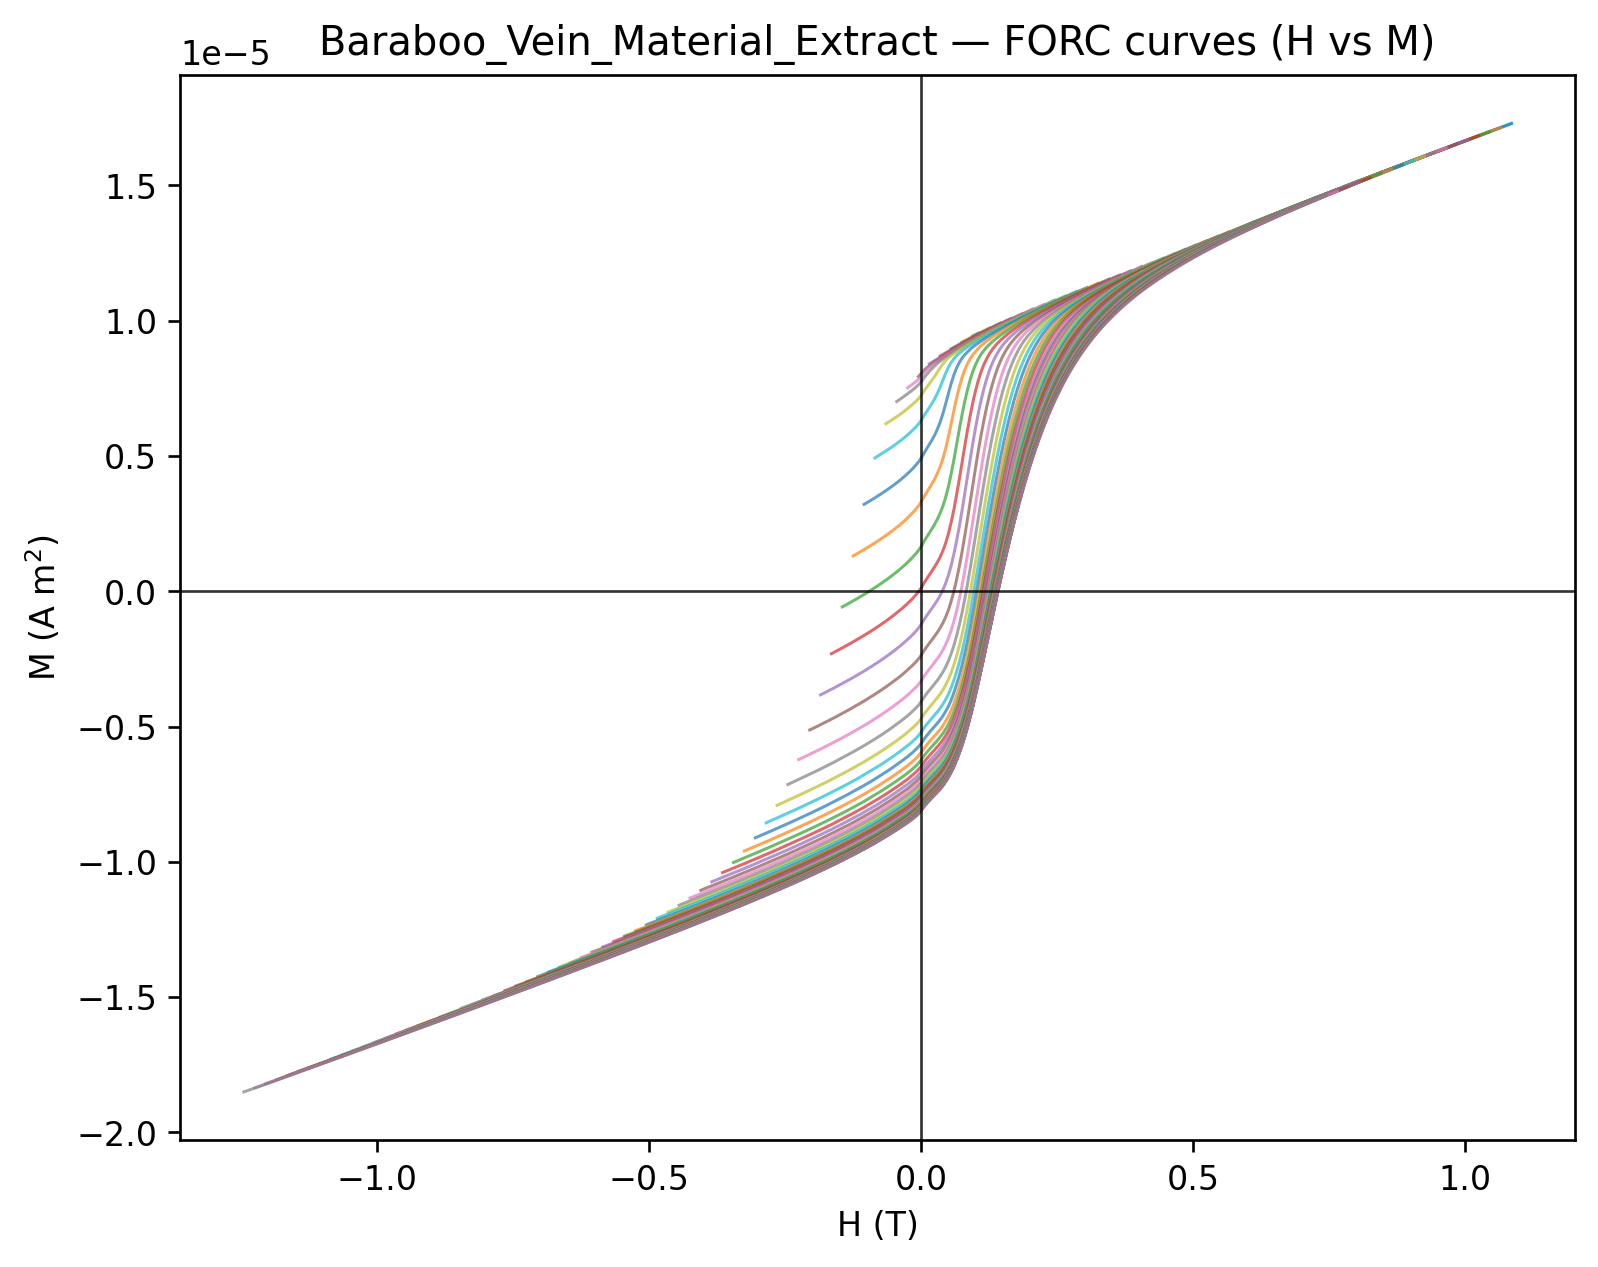

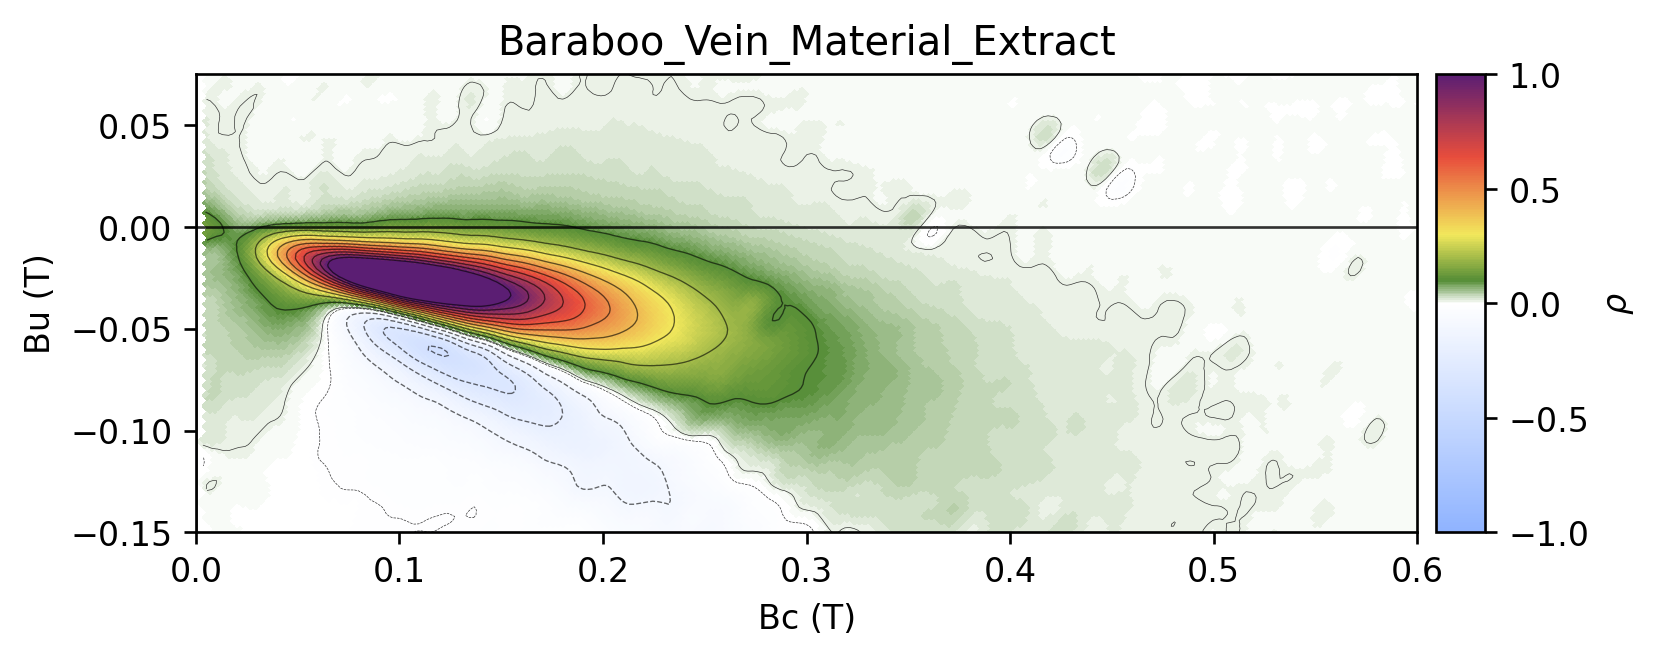

In [2]:
out = forc.process_forc(
    mode='m',
    path='../example_data/FORC/baraboo_vein_MagIC/measurements.txt',
    do_regrid=True,          # put the curves on a common field lattice
    B_step=0.005,            # at the 5 mT measurement increment
    Bu_min=-0.15,            # plotted window, asymmetric because this
    Bu_max=0.075,            # distribution sits below the Bu = 0 axis
    Bc_max=0.6,
    color_scale_version=2,
    plot_fraction=0.25,      # show a quarter of the measured curves
    display_upsample_factor=2,
    verbose=False,
)

The distribution has a peak offset below the B<sub>u</sub> = 0 axis, a coercivity distribution extending beyond 400 mT, and a negative region below the central peak. This combination has been documented for natural hematite ([Roberts et al., 2006](https://doi.org/10.1029/2006JB004715)).

Profiles through the peak quantify these characteristics: ρ against B<sub>c</sub> at the peak B<sub>u</sub>, and ρ against B<sub>u</sub> at the peak B<sub>c</sub>, each with a peak position and width.

Peak rho point inside bounded plot area:
  Bu = -0.027500 T
  Bc = 0.107500 T
  rho = 1.000000

Additional smoothing is applied to the profiles, which changes the peak rho, Bc and Bu values:
  Peak Bu on profile = -0.022500 T
  Peak Bc on profile = 0.112500 T
  Bu-profile FWHM = 0.035725 T
 


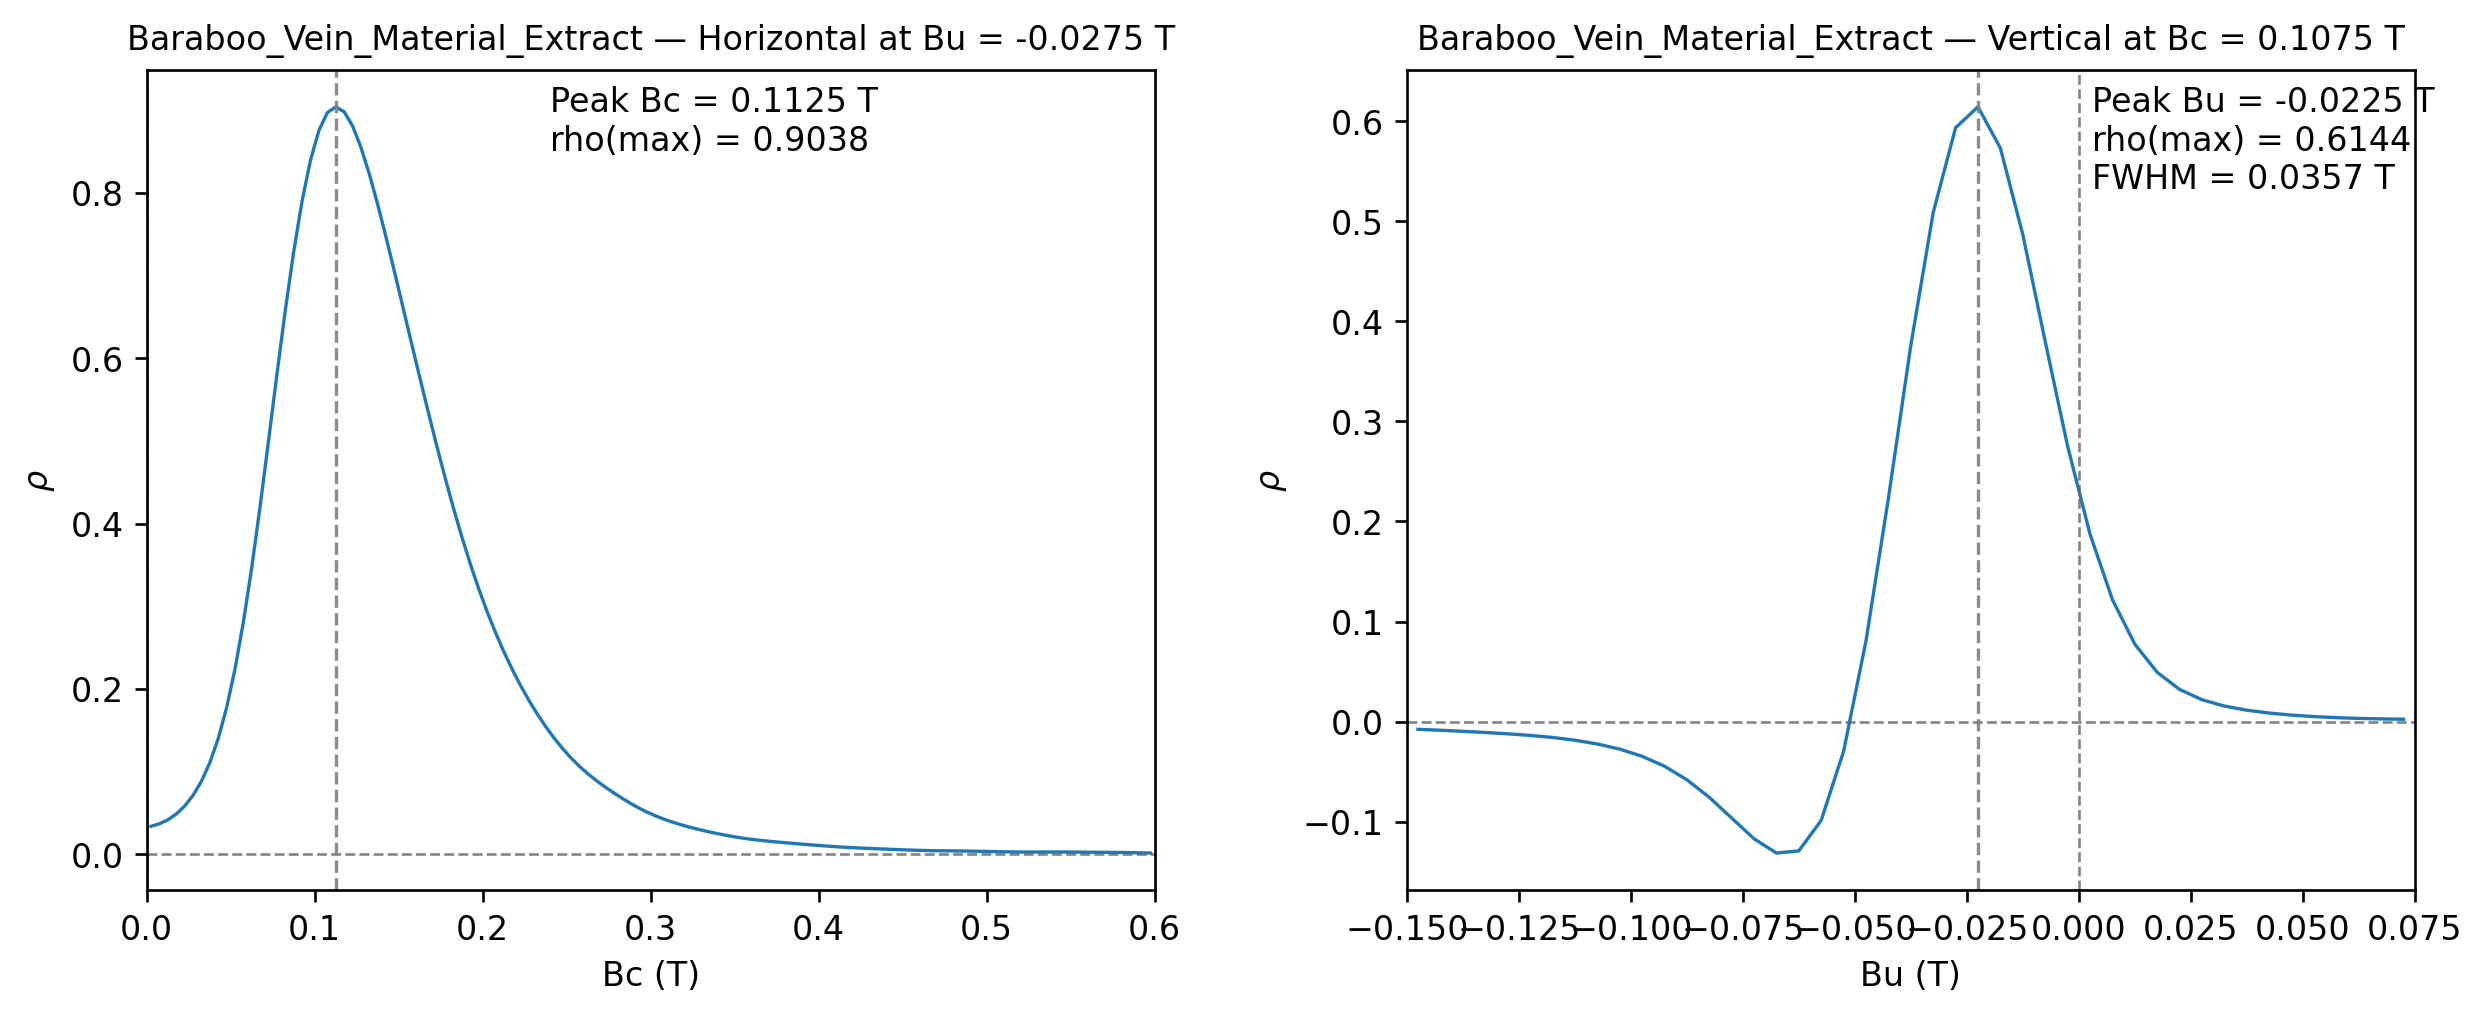

In [3]:
forc.plot_auto_forc_profiles(out, smooth_sigma_bins=2.5, export_txt=False,
                             export_png=False)

A fixed-B<sub>u</sub> cut assumes the crest of the distribution stays at one B<sub>u</sub>. For this sample, that assumption does not hold: the crest drifts to more negative B<sub>u</sub> as coercivity increases, so a horizontal cut through the peak comes off the ridge. The function `ridge_profile` shows values along the crest instead.

In [4]:
ridge = forc.ridge_profile(out['Ha_vals_used'], out['Hb_vals_used'], out['rho'],
                           Bu_min=-0.15, Bu_max=0.05, Bc_min=0.01, Bc_max=0.5)

peak = forc.find_bounded_peak_rho(out['Ha_vals_used'], out['Hb_vals_used'], out['rho'])
horizontal = forc.slice_profile_smoothed(
    out['Ha_vals_used'], out['Hb_vals_used'], out['rho'],
    mode='Bu', target=peak['bu'], x_min=0.0, x_max=0.6, bin_width=0.001,
    smooth_sigma_bins=2.5)

print(f"peak of the distribution : Bc = {1e3 * peak['bc']:.1f} mT, "
      f"Bu = {1e3 * peak['bu']:.1f} mT")
print(f"crest Bu range           : {1e3 * np.nanmin(ridge['bu']):.1f} to "
      f"{1e3 * np.nanmax(ridge['bu']):.1f} mT")
print(f"FWHM, fixed-Bu profile   : {1e3 * horizontal['peak']['fwhm']:.0f} mT")
print(f"FWHM, along the crest    : {1e3 * ridge['peak']['fwhm']:.0f} mT")

peak of the distribution : Bc = 107.5 mT, Bu = -27.5 mT
crest Bu range           : -97.6 to -2.6 mT
FWHM, fixed-Bu profile   : 103 mT
FWHM, along the crest    : 123 mT


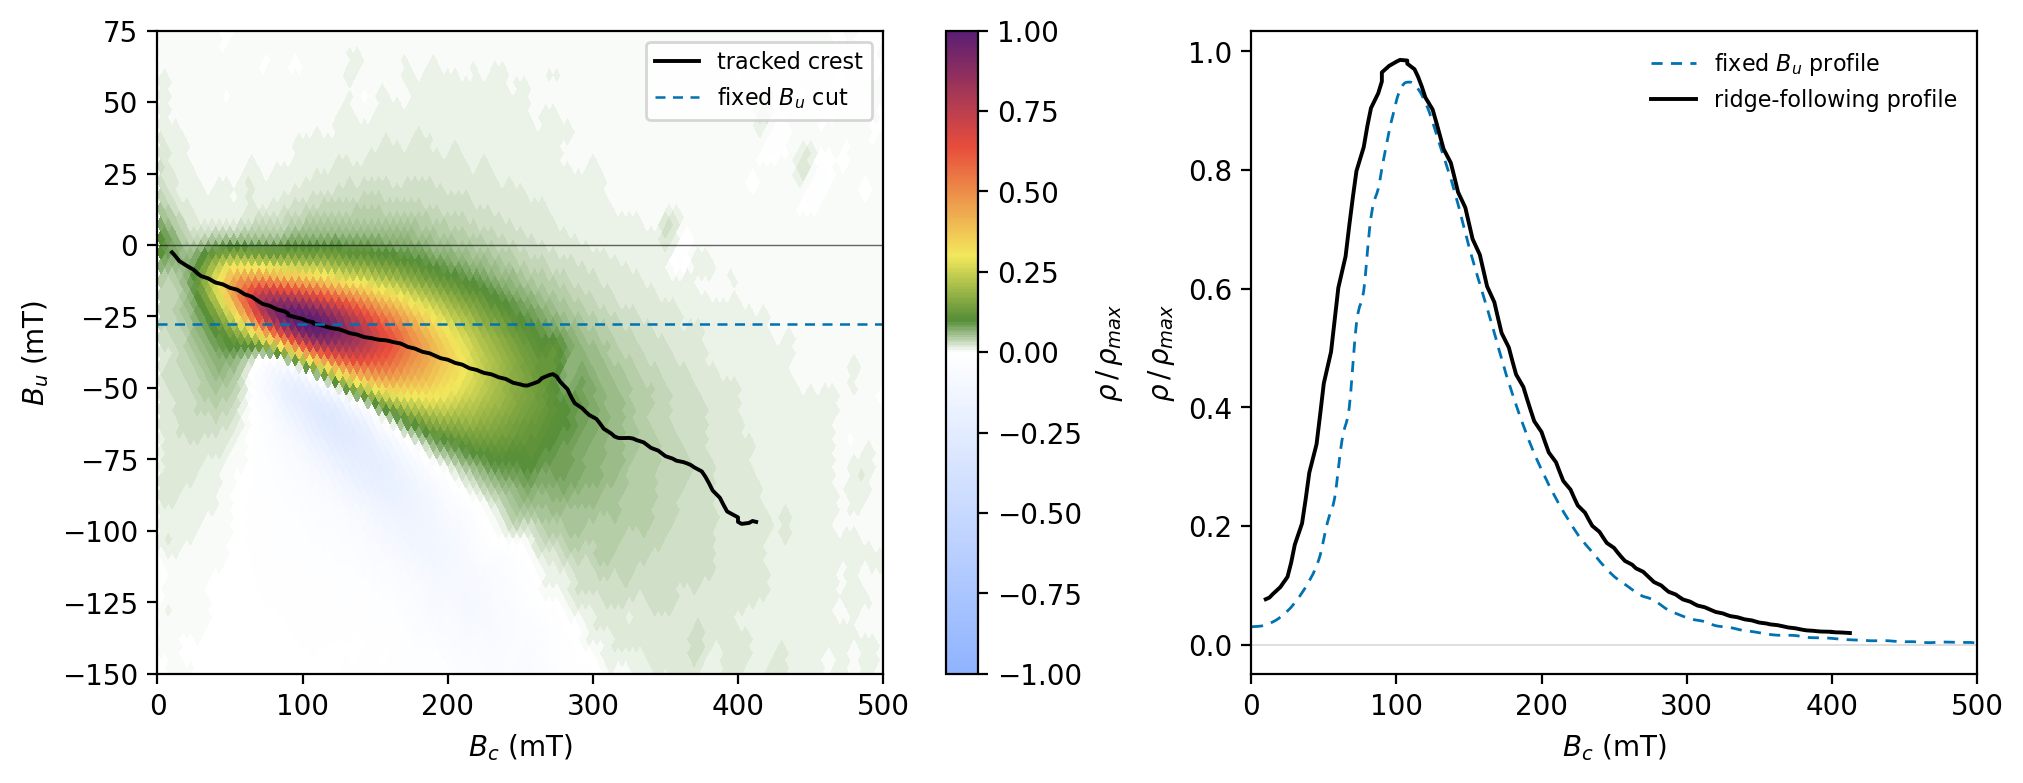

In [5]:
fig, (ax_map, ax_prof) = plt.subplots(1, 2, figsize=(10, 3.8), constrained_layout=True)

Ha, Hb, rho = out['Ha_vals_used'], out['Hb_vals_used'], out['rho']
vmax = forc.rho_window_vmax(Ha, Hb, rho, pct=100, Bu_min=-0.15, Bu_max=0.075,
                             Bc_min=0.0, Bc_max=0.6)
Ha_e, Hb_e = np.meshgrid(forc.centers_to_edges(Ha),
                         forc.centers_to_edges(Hb), indexing='ij')
mesh = ax_map.pcolormesh(1e3 * 0.5 * (Hb_e - Ha_e), 1e3 * 0.5 * (Hb_e + Ha_e),
                         rho / vmax, cmap=forc.get_forc_cmap(2),
                         vmin=-1, vmax=1, shading='auto')
ax_map.plot(1e3 * ridge['bc'], 1e3 * ridge['bu'], 'k-', lw=1.4, label='tracked crest')
ax_map.axhline(1e3 * peak['bu'], color='#0072B2', lw=0.9, ls=(0, (4, 3)),
               label=r'fixed $B_u$ cut')
ax_map.axhline(0, color='k', lw=0.5, alpha=0.6)
ax_map.set_xlim(0, 500)
ax_map.set_ylim(-150, 75)
ax_map.set_xlabel(r'$B_c$ (mT)')
ax_map.set_ylabel(r'$B_u$ (mT)')
ax_map.legend(fontsize=8, loc='upper right')
fig.colorbar(mesh, ax=ax_map, label=r'$\rho\,/\,\rho_{max}$', fraction=0.046)

ax_prof.plot(1e3 * horizontal['x'], horizontal['y'] / vmax, color='#0072B2',
             lw=1.0, ls=(0, (4, 3)), label=r'fixed $B_u$ profile')
ax_prof.plot(1e3 * ridge['bc'], ridge['rho'] / vmax, 'k-', lw=1.4,
             label='ridge-following profile')
ax_prof.axhline(0, color='0.85', lw=0.6)
ax_prof.set_xlim(0, 500)
ax_prof.set_xlabel(r'$B_c$ (mT)')
ax_prof.set_ylabel(r'$\rho\,/\,\rho_{max}$')
ax_prof.legend(frameon=False, fontsize=8)
plt.show()

The ridge-following profile recovers amplitude on the high-coercivity limb that the fixed-B<sub>u</sub> cut misses.

Each processing decision is recorded in the returned dictionary, so a diagram can be reported together with the choices that produced it.

In [6]:
loess = out['loess_params']
print(f"calibration points : {out['n_calibration_points']}")
print(f"drift correction   : {out['drift_corrected']} ({out['drift_fit']})")
print(f"grid               : {out['rho'].shape[0]} reversal x "
      f"{out['rho'].shape[1]} applied fields, {1e3 * out['dHa_used']:.0f} mT steps")
print(f"LOESS spans        : {1e3 * loess['span_Ha_T_used']:.0f} mT x "
      f"{1e3 * loess['span_Hb_T_used']:.0f} mT, min_pts = {loess['min_pts_used']}")

calibration points : 270
drift correction   : True (linear)
grid               : 268 reversal x 468 applied fields, 5 mT steps
LOESS spans        : 25 mT x 25 mT, min_pts = 34


## 2. The marginal coercivity distribution

Integrating &rho; along the interaction-field axis at each coercivity collapses the
diagram to one dimension,

$$f(B_c) = \int \rho(B_c, B_u)\, dB_u,$$

which is the coercivity distribution the assemblage would show in the absence of
interactions. It is directly comparable to a coercivity distribution obtained by
differentiating a backfield demagnetization curve, and to the components recovered by
unmixing (see
[coercivity_unmixing.ipynb](../hysteresis_backfield_notebooks/coercivity_unmixing.ipynb)),
so it provides a bridge between FORC analysis and the more widely applied
coercivity-spectrum methods.

Two things are worth keeping in mind. The integral runs over the $B_u$ window given, so a
window that clips the tails of an offset distribution — as a hematite distribution
centred well below $B_u = 0$ would be — will underestimate $f$. And because the
integration averages along $B_u$, the result is much less sensitive to the smoothing level
than the two-dimensional diagram is.


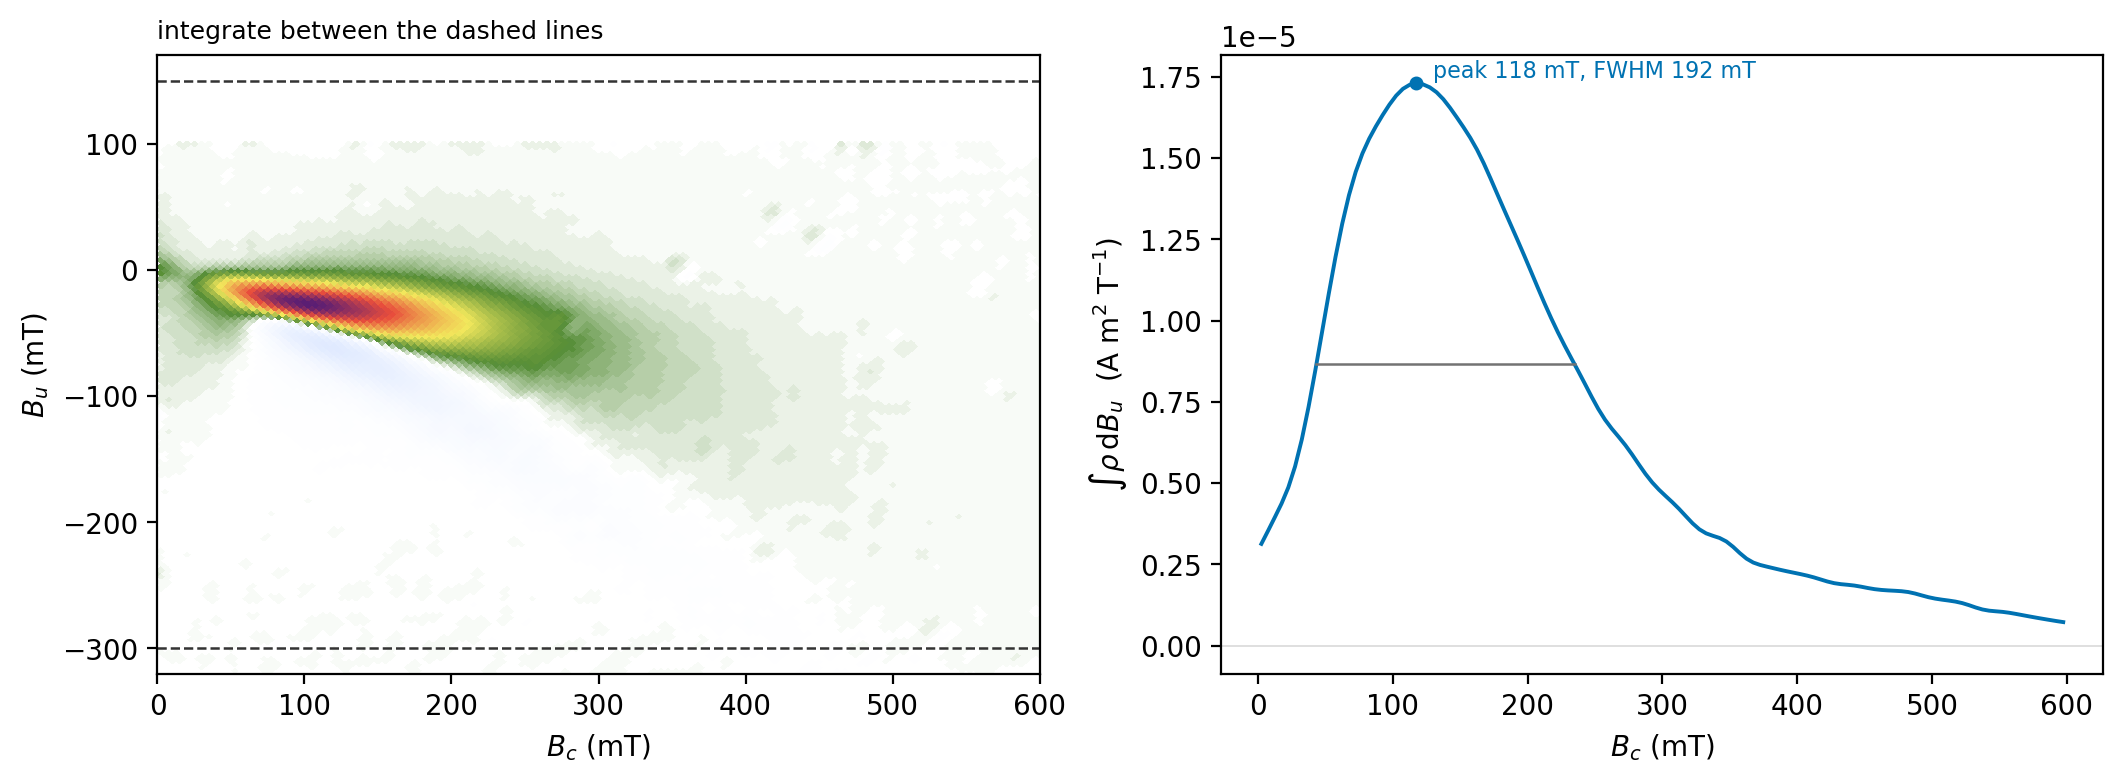

peak    118 mT
FWHM    192 mT


In [14]:
cdist = forc.coercivity_distribution(
    out['Ha_vals_used'], out['Hb_vals_used'], out['rho'],
    Bu_min=-0.30, Bu_max=0.15, Bc_max=0.60, smooth_sigma_bins=2.0,
)

fig, (ax_map, ax_cd) = plt.subplots(1, 2, figsize=(10.5, 3.8),
                                    constrained_layout=True)

# the diagram, with the integration window marked
Ha, Hb, rho = out['Ha_vals_used'], out['Hb_vals_used'], out['rho']
vmax = forc.rho_window_vmax(Ha, Hb, rho, pct=100, Bu_min=-0.15, Bu_max=0.075,
                             Bc_min=0.0, Bc_max=0.6)
Ha_e, Hb_e = np.meshgrid(forc.centers_to_edges(Ha),
                         forc.centers_to_edges(Hb), indexing='ij')
ax_map.pcolormesh(1e3 * 0.5 * (Hb_e - Ha_e), 1e3 * 0.5 * (Hb_e + Ha_e), rho / vmax,
                  cmap=forc.get_forc_cmap(2), vmin=-1, vmax=1, shading='auto')
ax_map.axhline(-300, color='0.2', lw=0.9, ls='--')
ax_map.axhline(150, color='0.2', lw=0.9, ls='--')
ax_map.set_xlim(0, 600)
ax_map.set_ylim(-320, 170)
ax_map.set_xlabel(r'$B_c$ (mT)')
ax_map.set_ylabel(r'$B_u$ (mT)')
ax_map.set_title('integrate between the dashed lines', fontsize=9, loc='left')

forc.plot_coercivity_distribution(cdist, ax=ax_cd)
plt.show()

print(f"peak    {1e3 * cdist['peak']['peak_x']:.0f} mT")
print(f"FWHM    {1e3 * cdist['peak']['fwhm']:.0f} mT")


The marginal peak at 118 mT sits close to the 108 mT peak of the two-dimensional diagram. The width is different: 192 mT here against 103 mT for the fixed-$B_u$ horizontal profile and 123 mT along the tracked crest. A cut samples one line through the distribution, whereas this integrates every line, so it picks up the coercivity spread carried by the parts of the distribution that lie away from the crest.

That is the standard workflow. The rest of the notebook explains what those calls did
and where the choices matter.

## 3. The measurement and the distribution

A FORC is a partial hysteresis curve that samples the interior of the major loop
([Pike et al., 1999](https://doi.org/10.1063/1.370176)). Each curve is measured by
applying a positive saturating field, decreasing the field along the descending branch of
the major loop to a **reversal field** $H_a$, and then measuring the magnetization $M$ at
increasing field steps as the field is returned from $H_a$ to the maximum field. The field
at which each measurement is made is the **applied field** $H_b$, and by construction
$H_b \geq H_a$.

Repeating this for successively lower reversal fields, resaturating before each curve,
fills the region enclosed by the major loop and defines the magnetization surface
$M(H_a, H_b)$ on the half-plane $H_b \geq H_a$. The FORC distribution is its mixed second
derivative,

$$\rho(H_a, H_b) = -\frac{1}{2}\,\frac{\partial^2 M(H_a, H_b)}{\partial H_a \, \partial H_b},$$

conventionally displayed in the rotated coordinates

$$B_c = \frac{H_b - H_a}{2}, \qquad B_u = \frac{H_b + H_a}{2},$$

with $B_c$ a coercivity axis and $B_u$ an interaction or bias axis.

Because ρ is a second derivative of measured data, it cannot be estimated without
smoothing. `pmagpy.forc` fits a weighted local quadratic surface (LOESS with tricube
weights) over an elliptical neighbourhood of each grid node and reads ρ off the
mixed-derivative coefficient. The size of that neighbourhood is the **LOESS span**, and it
is the one consequential analytical choice in FORC processing.

`pmagpy.forc` uses these symbols with the meanings above, matching Pike et al. (1999),
Roberts et al. (2000), [Harrison and Feinberg (2008)](https://doi.org/10.1029/2008GC001987)
and [Egli (2013)](https://doi.org/10.1016/j.gloplacha.2013.08.003). Fields are handled in
tesla and moments in A m² throughout.

One naming collision is worth flagging: MicroMag file headers use `Hb1`/`Hb2` for the
**bias axis** limits of the FORC diagram and `Hc1`/`Hc2` for the **coercivity axis**
limits. Those are display bounds, unrelated to the reversal and applied fields.
`pmagpy.forc` reads them into `Bu_max` and `Bc_max`.

## 4. Reading raw instrument files

The workflow above started from the MagIC table. Starting from the raw instrument file is
a one-argument change (`mode='i'`), but it is worth seeing what the reader works out.

MicroMag writes either SI or cgs depending on an instrument setting, and older exports
default to cgs. Reading Oe as tesla would introduce a silent factor of 10⁴, so the units
are resolved explicitly and the converted field range is range-checked.

In [7]:
raw_file = '../example_data/FORC/baraboo_vein_material_hematite.txt'

units = forc.read_file_units(raw_file)
print(f"field in {units['field_unit']}, moment in {units['moment_unit']} "
      f"(determined from the {units['source']})")

tags, data_start = forc.read_header_tags_and_data_start(raw_file)
for name in ['HCal', 'HSat', 'Hb1', 'Hb2', 'Hc1', 'Hc2', 'NForc']:
    if name in tags:
        print(f"  {name:6s} {tags[name]:g}")

field in T, moment in A m^2 (determined from the units line)
  HCal   1.1
  HSat   1.8
  Hb1    -0.25
  Hb2    0.1
  Hc2    1
  NForc  270


Header tags are reported in tesla after conversion. `HCal` is the field at which the
calibration measurements are made, `HSat` the saturating field applied before each curve.

The numeric section is then split into calibration points and reversal curves. Rows may
carry a third column (temperature on some exports), and blocks may be separated by blank
lines, by a large downward jump in field, or by the calibration-point pattern.

In [8]:
segments, _ = forc.phase1_prepare_segments_dual(raw_file, export_magic=False)

cal = [s for s in segments if s.kind == 'cal']
curves = [s for s in segments if s.kind == 'forc']
print(f"\n{len(cal)} calibration points, {len(curves)} reversal curves")
print(f"reversal fields Ha span {min(s.Ha for s in curves):+.3f} to "
      f"{max(s.Ha for s in curves):+.3f} T")

Parsed 269 curve blocks and 270 calibration points | curve length min/median/max = 3/271/399
Drift correction (linear) from 270 calibration points: +1.321e-08 A m^2 over the run

270 calibration points, 269 reversal curves
reversal fields Ha span -1.245 to +0.095 T


## 5. Drift correction

A calibration measurement is made at a fixed field before every reversal curve. Any change
in the measured moment at that field over the run is instrument drift, and it is removed by
interpolating the calibration record across the measurement sequence.

If fewer than two calibration points are identified the pipeline says so explicitly rather
than silently returning uncorrected curves, and `out['drift_corrected']` records what
happened.

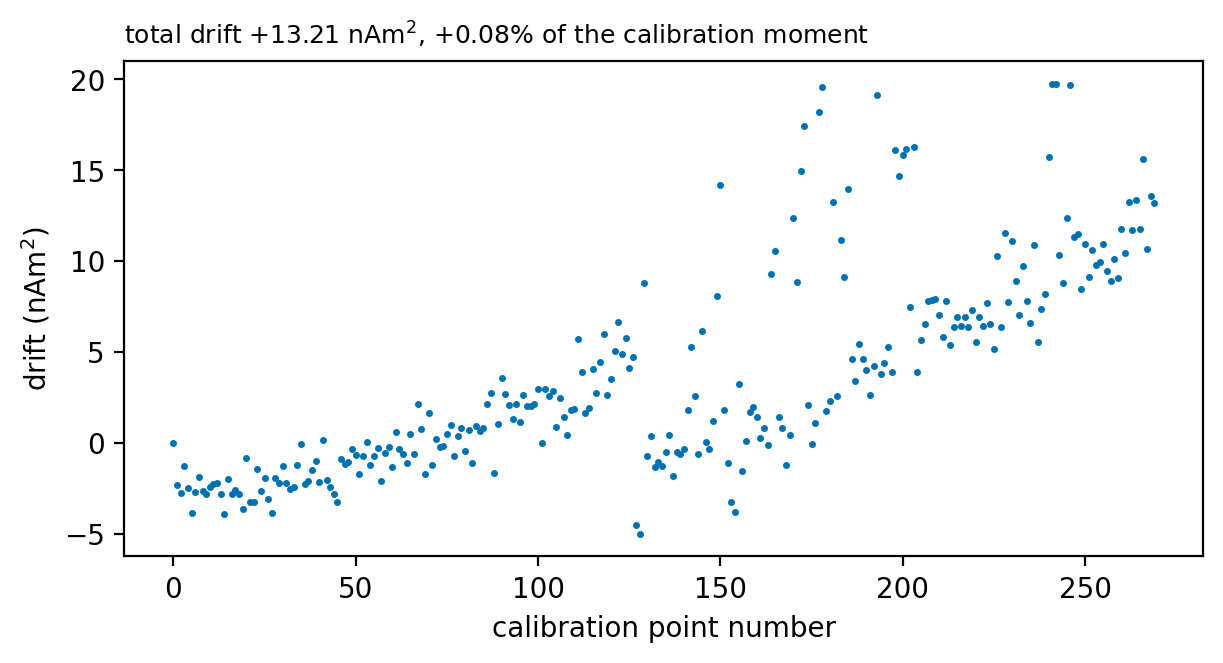

In [9]:
segments_raw = forc.read_segments_raw(raw_file, HCal=float(tags['HCal']), verbose=False)
segments_raw = forc.split_cal_first_point(segments_raw, HCal=float(tags['HCal']))
drift, cal_pos, cal_M = forc.compute_drift_from_cals(segments_raw, fit='linear')

fig, ax = plt.subplots(figsize=(6, 3.2), constrained_layout=True)
ax.plot(np.arange(cal_M.size), 1e9 * (cal_M - cal_M[0]), '.', ms=3, color='#0072B2')
ax.set_xlabel('calibration point number')
ax.set_ylabel('drift (nAm$^2$)')
ax.set_title(f'total drift {1e9 * (cal_M[-1] - cal_M[0]):+.2f} nAm$^2$, '
             f'{100 * (cal_M[-1] - cal_M[0]) / cal_M[0]:+.2f}% of the calibration moment',
             fontsize=9, loc='left')
plt.show()

The drift here is small but systematic, and removing it is cheap; for this specimen
it changes ρ by at most about 1% of the distribution maximum. `drift_fit='pchip'` uses a
monotone piecewise-cubic interpolation when the drift is not linear.

## 6. Archiving to MagIC

A published FORC diagram cannot be re-smoothed or reprocessed from the figure alone, and
FORC data have rarely been archived at the measurement level.
`export_magic_measurements_from_raw` writes each field–moment pair as a row of a MagIC
measurements table under the `LP-FORC` method code, **including the calibration
measurements**, so the drift correction remains reproducible from the archive.

In [10]:
magic_file = forc.export_magic_measurements_from_raw(
    raw_file,
    out_dir='../example_data/FORC/baraboo_vein_MagIC',
    filename='measurements.txt',
    specimen='Baraboo_Vein_Material_Extract',
    experiment='IRM_VSM_Lake_Shore-LP-FORC-251142',
    instrument_codes='IRM_VSM_Lake_Shore',
    meas_temp_k=294,
    citations='This study',
)
print(f'wrote {magic_file}')

wrote ../example_data/FORC/baraboo_vein_MagIC/measurements.txt


The result is a standard MagIC measurements table, readable with the same tools used
throughout these notebooks.

In [11]:
import pmagpy.contribution_builder as cb

contribution = cb.Contribution('../example_data/FORC/baraboo_vein_MagIC')
measurements = contribution.tables['measurements'].df
print(f"{len(measurements)} measurements, "
      f"method codes {list(measurements['method_codes'].unique())}")
measurements[['measurement', 'specimen', 'meas_field_dc', 'magn_moment']].head()

-I- Using online data model


-I- Getting method codes from earthref.org


-I- Importing controlled vocabularies from https://earthref.org


68200 measurements, method codes ['LP-FORC']


,measurement,specimen,meas_field_dc,magn_moment
measurement name,,,,
IRM_VSM_Lake_Shore-LP-FORC-251142-1-0,IRM_VSM_Lake_Shore-LP-FORC-251142-1-0,Baraboo_Vein_Material_Extract,1.099403,0.000017
IRM_VSM_Lake_Shore-LP-FORC-251142-1-1,IRM_VSM_Lake_Shore-LP-FORC-251142-1-1,Baraboo_Vein_Material_Extract,0.100000,0.000009
IRM_VSM_Lake_Shore-LP-FORC-251142-2-0,IRM_VSM_Lake_Shore-LP-FORC-251142-2-0,Baraboo_Vein_Material_Extract,1.099424,0.000017
IRM_VSM_Lake_Shore-LP-FORC-251142-2-1,IRM_VSM_Lake_Shore-LP-FORC-251142-2-1,Baraboo_Vein_Material_Extract,0.095000,0.000009
IRM_VSM_Lake_Shore-LP-FORC-251142-2-2,IRM_VSM_Lake_Shore-LP-FORC-251142-2-2,Baraboo_Vein_Material_Extract,0.100000,0.000009


The point of archiving the measurements is that nothing is lost. Processing the raw
instrument file directly and processing the MagIC table give the same distribution.

In [12]:
out_raw = forc.process_forc(
    mode='i', path=raw_file, do_regrid=True, B_step=0.005,
    plot_hyst=False, plot_rho=False, verbose=False,
)

shared = np.isfinite(out['rho']) & np.isfinite(out_raw['rho'])
difference = np.max(np.abs(out['rho'][shared] - out_raw['rho'][shared]))
print(f"shared grid cells        : {shared.sum()}")
print(f"max |rho_MagIC - rho_raw|: {difference:.3e} "
      f"({difference / np.nanmax(np.abs(out_raw['rho'])):.1e} of the maximum)")

shared grid cells        : 67662
max |rho_MagIC - rho_raw|: 0.000e+00 (0.0e+00 of the maximum)


## 7. Choosing the smoothing level

Double differentiation amplifies measurement noise, so some smoothing is unavoidable, and
how much is applied changes the result. `guess_loess_params` sets a starting point from
the geometry of the measurement rather than from the data values, and `smooth_strength`
scales it. The figure below shows the same data across a factor of six in window size.


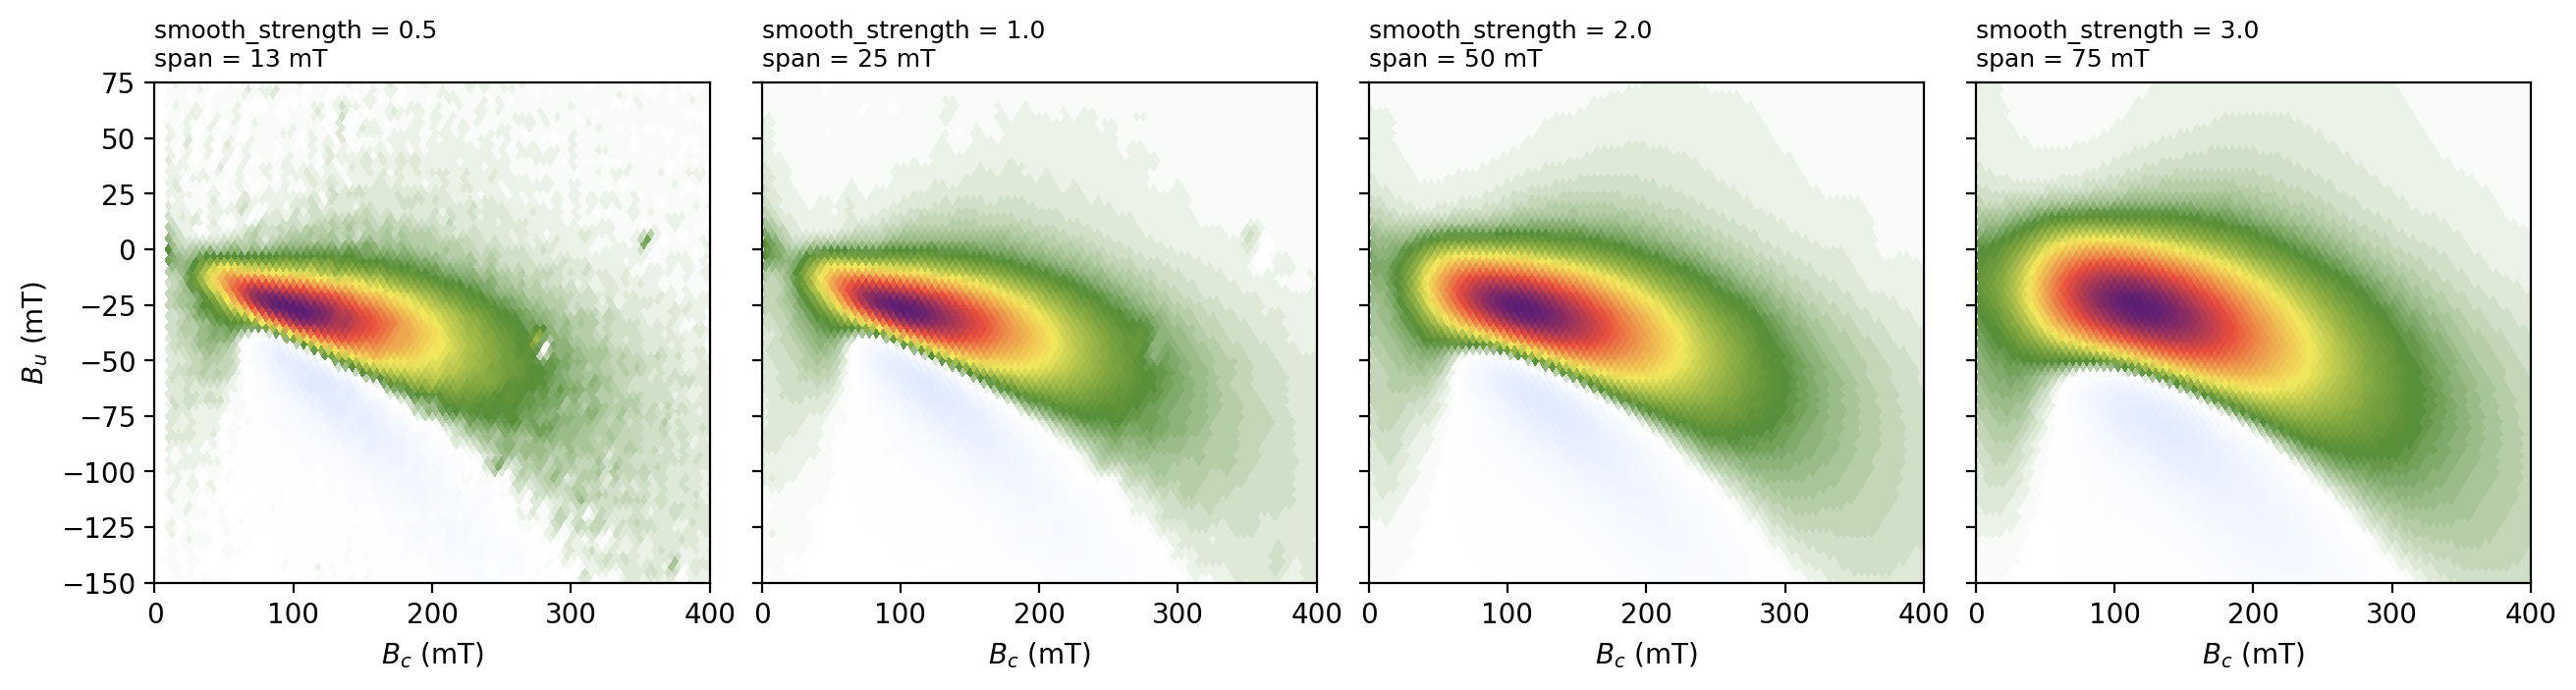

In [13]:
strengths = [0.5, 1.0, 2.0, 3.0]
fig, axes = plt.subplots(1, len(strengths), figsize=(13, 3.4),
                         constrained_layout=True, sharey=True)

for ax, strength in zip(axes, strengths):
    trial = forc.process_forc(
        mode='i', path=raw_file, do_regrid=True, B_step=0.005,
        smooth_strength=strength, plot_hyst=False, plot_rho=False, verbose=False,
    )
    Ha, Hb, rho = trial['Ha_vals_used'], trial['Hb_vals_used'], trial['rho']
    vmax = forc.rho_window_vmax(Ha, Hb, rho, pct=100, Bu_min=-0.15, Bu_max=0.075,
                                 Bc_min=0.0, Bc_max=0.6)
    Ha_e, Hb_e = np.meshgrid(forc.centers_to_edges(Ha),
                             forc.centers_to_edges(Hb), indexing='ij')
    ax.pcolormesh(1e3 * 0.5 * (Hb_e - Ha_e), 1e3 * 0.5 * (Hb_e + Ha_e), rho / vmax,
                  cmap=forc.get_forc_cmap(2), vmin=-1, vmax=1, shading='auto')
    ax.set_xlim(0, 400)
    ax.set_ylim(-150, 75)
    ax.set_xlabel(r'$B_c$ (mT)')
    span = 1e3 * trial['loess_params']['span_Ha_T_used']
    ax.set_title(f'smooth_strength = {strength}\nspan = {span:.0f} mT',
                 fontsize=9, loc='left')

axes[0].set_ylabel(r'$B_u$ (mT)')
plt.show()

The peak position is stable across this range; its width is not. Report the spans in
`out['loess_params']` with any diagram.

[FORC_smoothing.ipynb](./FORC_smoothing.ipynb) develops this: what the neighbourhood is,
how much of it is usable near the B<sub>c</sub> = 0 axis, what over- and under-smoothing do
to a feature of known width, a residual-based criterion for choosing a level, and why a
single window cannot serve a narrow ridge and a broad background at once.

### A note on profile binning

Profiles are binned at the grid step over the requested window. This matters here: the
lowest reversal curves reach $-1.245$ T, so a fixed number of bins spread over the full
measured range would be far coarser than the plotted window and would quantize the
reported peak position. `smooth_sigma_bins` is a Gaussian sigma **in bins**, so its
physical width scales with the bin width. `plot_custom_forc_profiles` takes user-chosen
B<sub>u</sub> and B<sub>c</sub> values rather than the peak, for interrogating a shoulder
or a secondary feature.


## 8. Relationship to other FORC packages

The processing lineage of FORC analysis is largely a lineage of smoothing strategies, and
it is worth being explicit about where `pmagpy.forc` sits relative to the packages in
widest use.

| | Roberts et al. (2000) | FORCinel | VARIFORC | FORCsensei | `pmagpy.forc` |
|---|---|---|---|---|---|
| smoothing | polynomial over a square neighbourhood, integer smoothing factor | LOESS, tricube weights | LOESS with spatially variable smoothing factors | constant and VARIFORC-style variable smoothing | LOESS tricube, or VARIFORC-style variable smoothing |
| smoothing selection | user | residual-based optimum smoothing factor | user-set factors with limits along $B_c$, $B_b$ and the diagonals | Bayesian model selection over a parameter grid | automated from measurement geometry, scaled by `smooth_strength`; VARIFORC presets |
| variable smoothing | no | yes (VARIFORC implemented) | yes | yes | yes |
| uncertainty on &rho; | no | no | error matrix, signal-to-noise threshold, confidence intervals | full posterior over smoothing models | propagated standard error and signal-to-noise ratio per cell |
| central-ridge isolation | no | yes (`IsolateCR`) | yes | no | no |
| marginal coercivity distribution | no | yes | yes | no | yes |
| $B_c$ &asymp; 0 behaviour | truncated | constant smoothing maintained to the axis | explicit lower-diagonal trim factor | as VARIFORC | half-window near the diagonal; optional `edge_mask_bc_bins` |
| output grid | measurement grid | measurement grid | independent output mesh | measurement grid | measurement grid, optional regridding |
| MagIC read/write | no | no | no | no | yes |
| platform | — | Igor Pro (commercial) | Mathematica (commercial) | Python, MIT | Python, open source |

The variable-smoothing kernel was written from the equations of Egli (2013) rather than
from any existing code, and it is checked in two independent ways. It reproduces Egli's
published resolution law (his Eq. 9) for the processed width of a synthetic ridge, and it
agrees with FORCsensei — an independently written implementation of the same protocol —
to within 1 &times; 10<sup>-11</sup> of the peak amplitude on both case-study datasets
distributed with that package, under constant and variable smoothing alike. That is the
level of floating-point accumulation order. [FORC_variforc.ipynb](./FORC_variforc.ipynb)
shows these comparisons.

Two gaps remain relative to FORCinel. `pmagpy.forc` does not implement central-ridge
isolation or the mean-field correction, and it computes the distribution on the
measurement grid rather than on an independent output mesh — VARIFORC's decoupled mesh
allows datasets measured with different protocols to be combined without interpolation.

What `pmagpy.forc` adds is not a new estimator but integration: the same processing sits
in the Python environment where the rest of a rock magnetic workflow is carried out, its
parameters are recorded in the output rather than in a session, and it reads and writes
the MagIC data model directly — a fully scriptable path from the raw instrument file
through an archived measurements table to a reproducible diagram.

## Summary

- `process_forc` takes a raw MicroMag file or a MagIC measurements table to a
  finished diagram in one call; `mode` selects individual, batch, stacked, or MagIC input.
- Units are resolved from the file rather than assumed, and a file whose declared units
  are inconsistent with its data is rejected rather than silently rescaled.
- Drift is corrected from the interleaved calibration measurements, and the pipeline
  reports when it could not be.
- Export the measurements to MagIC (`export_magic_measurements_from_raw`). The archived
  table reproduces the distribution exactly, calibration points included.
- The smoothing level is the consequential choice. Assess results across a range of
  `smooth_strength` and report the spans in `out['loess_params']` with any diagram.
- Use `ridge_profile` rather than a fixed-B<sub>u</sub> cut where the crest of the
  distribution drifts with coercivity.
- `coercivity_distribution` collapses &rho; along B<sub>u</sub> to a one-dimensional
  coercivity distribution comparable with backfield-derived spectra.

## References

- Egli, R. (2013). VARIFORC: An optimized protocol for calculating non-regular first-order reversal curve (FORC) diagrams. *Global and Planetary Change*, 110, 302–320. https://doi.org/10.1016/j.gloplacha.2013.08.003
- Harrison, R. J., & Feinberg, J. M. (2008). FORCinel: An improved algorithm for calculating first-order reversal curve distributions using locally weighted regression smoothing. *Geochemistry, Geophysics, Geosystems*, 9, Q05016. https://doi.org/10.1029/2008GC001987
- Pike, C. R., Roberts, A. P., & Verosub, K. L. (1999). Characterizing interactions in fine magnetic particle systems using first order reversal curves. *Journal of Applied Physics*, 85, 6660–6667. https://doi.org/10.1063/1.370176
- Roberts, A. P., Pike, C. R., & Verosub, K. L. (2000). First-order reversal curve diagrams: A new tool for characterizing the magnetic properties of natural samples. *Journal of Geophysical Research*, 105, 28461–28475. https://doi.org/10.1029/2000JB900326
- Roberts, A. P., Liu, Q., Rowan, C. J., Chang, L., Carvallo, C., Torrent, J., & Horng, C.-S. (2006). Characterization of hematite (α-Fe₂O₃), goethite (α-FeOOH), greigite (Fe₃S₄), and pyrrhotite (Fe₇S₈) using first-order reversal curve diagrams. *Journal of Geophysical Research*, 111, B12S35. https://doi.org/10.1029/2006JB004715
- Roberts, A. P., Heslop, D., Zhao, X., & Pike, C. R. (2014). Understanding fine magnetic particle systems through use of first-order reversal curve diagrams. *Reviews of Geophysics*, 52, 557–602. https://doi.org/10.1002/2014RG000462
- Heslop, D., & Roberts, A. P. (2012). Estimation of significance levels and confidence intervals for first-order reversal curve distributions. *Geochemistry, Geophysics, Geosystems*, 13, Q12Z40. https://doi.org/10.1029/2012GC004115
- Heslop, D., Roberts, A. P., Oda, H., Zhao, X., Harrison, R. J., Muxworthy, A. R., Hu, P.-X., & Sato, T. (2020). An automatic model selection-based machine learning framework to estimate FORC distributions. *Journal of Geophysical Research: Solid Earth*, 125, e2020JB020418. https://doi.org/10.1029/2020JB020418
